# 🎧 Speech Emotion Recognition using MFCC & Machine Learning

This project focuses on identifying human emotions from speech signals using audio feature extraction (MFCC) and machine learning techniques.

**Dataset Used:** RAVDESS  
**Features:** MFCC (Mel Frequency Cepstral Coefficients)  
**Goal:** Classify emotions such as happy, sad, angry, calm, etc.


In [1]:
pip install librosa matplotlib numpy


   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 18.0 MB/s eta 0:00:00

   -------------------------- ------------- 6/9 [pooch]
   ----------------------------------- ---- 8/9 [librosa]
   ---------------------------------------- 9/9 [librosa]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("All imports OK ✅")


All imports OK ✅


## 🔹 Audio Signal Visualization

In this step, we load a single `.wav` file and visualize its waveform.  
The waveform represents the amplitude of the speech signal over time.

From this plot, we can clearly observe:
- Silence at the beginning and end
- Strong amplitude variations during speech
- This confirms that our audio file was loaded correctly

In [2]:
base_dir = "data" 

wav_files = []

for root, dirs, files in os.walk(base_dir):
    for f in files:
        if f.lower().endswith(".wav"):
            wav_files.append(os.path.join(root, f))

print("Total .wav files found:", len(wav_files))
wav_files[:5]


Total .wav files found: 2880


['data\\RAVDESS\\Actor_01\\03-01-01-01-01-01-01.wav',
 'data\\RAVDESS\\Actor_01\\03-01-01-01-01-02-01.wav',
 'data\\RAVDESS\\Actor_01\\03-01-01-01-02-01-01.wav',
 'data\\RAVDESS\\Actor_01\\03-01-01-01-02-02-01.wav',
 'data\\RAVDESS\\Actor_01\\03-01-02-01-01-01-01.wav']

In [3]:
sample_path = wav_files[0]
print("Using sample:", sample_path)

y, sr = librosa.load(sample_path, sr=None)  # sr=None = keep original sampling rate

print("Signal shape:", y.shape)
print("Sampling rate:", sr)


Using sample: data\RAVDESS\Actor_01\03-01-01-01-01-01-01.wav
Signal shape: (158558,)
Sampling rate: 48000


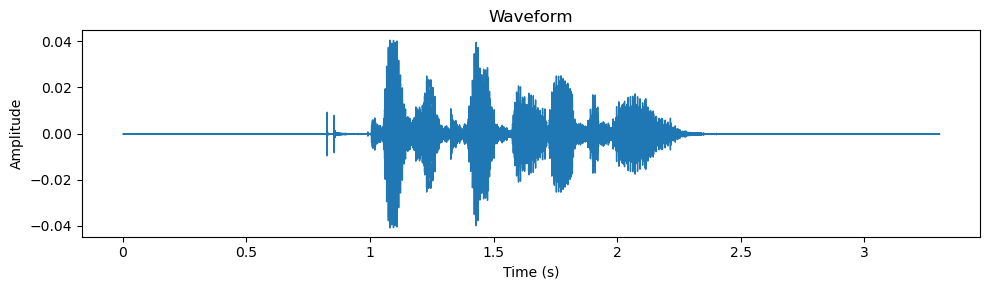

In [4]:
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## 🔹 MFCC Feature Extraction

MFCC (Mel Frequency Cepstral Coefficients) are widely used features in speech and audio processing.  
They capture important frequency patterns that help differentiate emotions in human speech.

Each audio file is converted into:
- **13 MFCC coefficients**
- Represented as a time–frequency heatmap

To make the data suitable for machine learning, we later convert these into fixed-length numerical vectors.


In [5]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print("MFCC shape:", mfcc.shape)


MFCC shape: (13, 310)


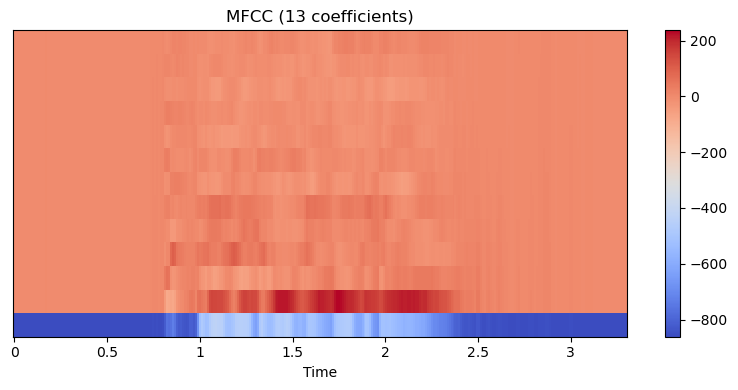

In [6]:
plt.figure(figsize=(8, 4))
librosa.display.specshow(mfcc, x_axis="time", sr=sr)
plt.colorbar()
plt.title("MFCC (13 coefficients)")
plt.tight_layout()
plt.show()


## 🔹 Emotion Label Mapping from Filenames

The RAVDESS dataset encodes emotion information directly inside the filename.  
We extract the emotion code and map it to the actual emotion label such as:

- Neutral  
- Calm  
- Happy  
- Sad  
- Angry  
- Fearful  
- Disgust  
- Surprised  

This allows automatic labeling of all audio samples without manual work.


In [10]:
import numpy as np

def extract_mfcc(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    # Convert (13, time_steps) → (13,) by taking mean
    mfcc_mean = np.mean(mfcc.T, axis=0)
    
    return mfcc_mean


In [9]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

def get_emotion_from_filename(file_path):
    filename = os.path.basename(file_path)
    emotion_code = filename.split("-")[2]
    return emotion_dict[emotion_code]


In [11]:
test_file = wav_files[0]

features = extract_mfcc(test_file)
emotion = get_emotion_from_filename(test_file)

print("Features length:", len(features))  # should be 13
print("Emotion:", emotion)


Features length: 13
Emotion: neutral


## 🔹 Bulk Feature Extraction 

In this step, MFCC features were extracted from **all 2880 audio files** in the dataset.  
Each audio file was converted into a **13-dimensional numerical feature vector**, and the corresponding emotion label was assigned.

This step transforms raw audio data into a fully structured numerical dataset suitable for machine learning.


In [10]:
import pandas as pd

X = []
y = []

for file in wav_files:
    try:
        mfcc_features = extract_mfcc(file)
        emotion_label = get_emotion_from_filename(file)
        
        X.append(mfcc_features)
        y.append(emotion_label)
        
    except Exception as e:
        print("Error with file:", file)


## 🔹 Final Structured Dataset

The final dataset consists of:
- **13 feature columns** representing MFCC coefficients
- **1 target column** representing the emotion label

Each row corresponds to one audio sample.  
This dataset is now ready for training machine learning models.


In [12]:
df = pd.DataFrame(X)
df["emotion"] = y

df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,emotion
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,-7.861652,-2.124282,2.849204,neutral
1,-719.128296,70.201569,1.168397,13.122543,7.836950,14.411292,-4.111360,4.468973,-3.539367,-3.658607,-7.648504,-1.477077,3.031821,neutral
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,-7.499283,-2.962265,1.873485,neutral
3,-710.975281,67.564888,5.782241,13.230726,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,-7.416558,-1.937004,2.271525,neutral
4,-759.921753,75.783524,6.023605,14.557394,6.454188,14.631508,-3.004551,4.620970,-5.200016,-0.707430,-7.790287,-3.564948,2.180970,calm


##  Dataset Saved Successfully

The preprocessed feature dataset has been saved as:

`speech_emotion_features.csv`

This file will be used in the next stage for:
- Data splitting  
- Model training  
- Performance evaluation


In [13]:
df.to_csv("speech_emotion_features.csv", index=False)
print("speech_emotion_features.csv saved successfully ✅")


speech_emotion_features.csv saved successfully ✅


# 🧠 Machine Learning Model Training

In this stage, we train machine learning models to classify human emotions using the MFCC features extracted from speech audio. The goal is to build a reliable model that can accurately predict emotions from voice signals.


## 🔹 Loading the Preprocessed Feature Dataset

The dataset generated in the previous step (`speech_emotion_features.csv`) is loaded into a pandas DataFrame.  
This dataset contains:
- 13 MFCC feature columns
- 1 target column representing the emotion label


In [13]:
import pandas as pd

df = pd.read_csv("speech_emotion_features.csv")
df.head(), df.shape


(           0         1         2          3         4          5         6  \
 0 -726.21720  68.54142  3.293398  12.205300  5.510278  13.667408 -2.983828   
 1 -719.12830  70.20157  1.168397  13.122543  7.836950  14.411292 -4.111360   
 2 -714.99570  69.68935  3.924564  11.924190  6.421723  11.011614 -2.878103   
 3 -710.97530  67.56489  5.782241  13.230726  6.190846  12.628252 -1.675169   
 4 -759.92175  75.78352  6.023605  14.557394  6.454188  14.631508 -3.004551   
 
           7         8         9        10        11        12  emotion  
 0  3.098029 -3.310813 -1.564384 -7.861652 -2.124282  2.849204  neutral  
 1  4.468973 -3.539367 -3.658608 -7.648504 -1.477078  3.031821  neutral  
 2  4.509558 -4.476109 -2.671549 -7.499283 -2.962265  1.873485  neutral  
 3  5.657494 -4.950634 -3.477546 -7.416558 -1.937004  2.271525  neutral  
 4  4.620970 -5.200016 -0.707430 -7.790287 -3.564948  2.180970     calm  ,
 (2880, 14))

## 🔹 Splitting Features and Target Labels

The dataset is divided into:
- **X (Features):** MFCC numerical values  
- **y (Target):** Emotion labels such as happy, sad, angry, etc.

This separation is required before feeding the data into machine learning models.


In [14]:
X = df.drop("emotion", axis=1)
y = df["emotion"]

X.shape, y.shape


((2880, 13), (2880,))

## 🔹 Encoding Emotion Labels

Machine learning models work with numerical values, not text labels.  
Therefore, emotion names such as *happy*, *sad*, and *angry* are converted into numerical class values using Label Encoding.

This step ensures the target variable is compatible with ML algorithms.


In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

label_encoder.classes_, y_encoded[:10]


(array(['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad',
        'surprised'], dtype=object),
 array([5, 5, 5, 5, 1, 1, 1, 1, 1, 1]))

## 🔹 Train-Test Data Split

The dataset is split into:
- **80% Training Data** – used to train the model  
- **20% Testing Data** – used to evaluate performance  

Stratified splitting is applied to preserve the class distribution across both sets.


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train.shape, X_test.shape


((2304, 13), (576, 13))

## 🔹 Feature Scaling

Feature scaling is applied using StandardScaler to normalize all MFCC features to a similar numerical range.

This step is essential because:
- It improves model convergence
- Prevents large numerical values from dominating smaller ones
- Enhances the performance of Logistic Regression and Neural Networks


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 🔹 Baseline Model – Logistic Regression

Logistic Regression is used as a baseline classifier to evaluate whether MFCC features can effectively separate different emotion classes.

This model provides a minimum benchmark accuracy before moving to more complex models.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("✅ Logistic Regression Accuracy:", log_accuracy)


✅ Logistic Regression Accuracy: 0.4548611111111111


## 🔹 Main Model – Neural Network (MLPClassifier)

A Multi-Layer Perceptron (MLP) neural network is used as the primary classification model.  
It consists of:
- Two hidden layers (128 and 64 neurons)
- ReLU activation function
- Adam optimizer

This model is capable of learning complex non-linear relationships in speech emotion data and generally achieves higher accuracy than baseline models.


In [20]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

print("✅ MLP Classifier Accuracy:", mlp_accuracy)



✅ MLP Classifier Accuracy: 0.9288194444444444


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## 🔹 Model Performance Comparison

The performance of both models is compared using accuracy scores.  
The model with higher test accuracy is selected as the final classifier for deployment.


In [21]:
print("Logistic Regression Accuracy:", log_accuracy)
print("MLP Classifier Accuracy:", mlp_accuracy)


Logistic Regression Accuracy: 0.4548611111111111
MLP Classifier Accuracy: 0.9288194444444444


# 📊 Model Evaluation & Performance Analysis

After training the machine learning models, this stage focuses on evaluating their performance using detailed metrics. Instead of relying only on accuracy, we analyze class-wise performance using Confusion Matrix and Classification Report.


## 🔹 Importance of Model Evaluation

Model evaluation helps us understand:
- Which emotions are classified correctly
- Which emotions are being confused with others
- Whether the model is biased toward any specific emotion

This step is critical for validating the real-world reliability of the trained model.


## 🔹 Classification Report

The classification report provides detailed performance metrics for each emotion class, including:

- **Precision:** How accurate the positive predictions are  
- **Recall:** How well the model identifies all actual samples of a class  
- **F1-Score:** A balance between precision and recall  
- **Support:** Number of actual samples for each class

These metrics provide a deeper understanding of model performance beyond overall accuracy.


In [23]:
from sklearn.metrics import classification_report

print("✅ Classification Report (MLP Model):\n")
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))


✅ Classification Report (MLP Model):

              precision    recall  f1-score   support

       angry       0.97      1.00      0.99        76
        calm       0.88      0.92      0.90        77
     disgust       0.97      0.87      0.92        77
     fearful       0.91      0.92      0.92        77
       happy       0.93      0.96      0.94        77
     neutral       1.00      1.00      1.00        38
         sad       0.94      0.87      0.91        77
   surprised       0.88      0.92      0.90        77

    accuracy                           0.93       576
   macro avg       0.93      0.93      0.93       576
weighted avg       0.93      0.93      0.93       576



## 🔹 Confusion Matrix

A Confusion Matrix is a performance evaluation table that compares:
- **Actual emotion labels**
- **Predicted emotion labels**

Each row represents the true emotion class, while each column represents the predicted class.

This matrix clearly shows:
- Correct predictions along the diagonal
- Misclassifications in the off-diagonal cells

It helps identify which emotions are frequently confused by the model.


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_mlp)
cm


array([[76,  0,  0,  0,  0,  0,  0,  0],
       [ 0, 71,  0,  0,  0,  0,  2,  4],
       [ 0,  4, 67,  2,  0,  0,  0,  4],
       [ 2,  2,  0, 71,  0,  0,  2,  0],
       [ 0,  0,  0,  3, 74,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 38,  0,  0],
       [ 0,  4,  0,  0,  4,  0, 67,  2],
       [ 0,  0,  2,  2,  2,  0,  0, 71]])

## 🔹 Interpreting Model Performance

Using the Confusion Matrix and Classification Report, we can:
- Analyze which emotions are well-classified
- Identify weak emotion classes
- Understand overall model strengths and limitations

This interpretation helps in further improving the model through feature engineering or hyperparameter tuning.


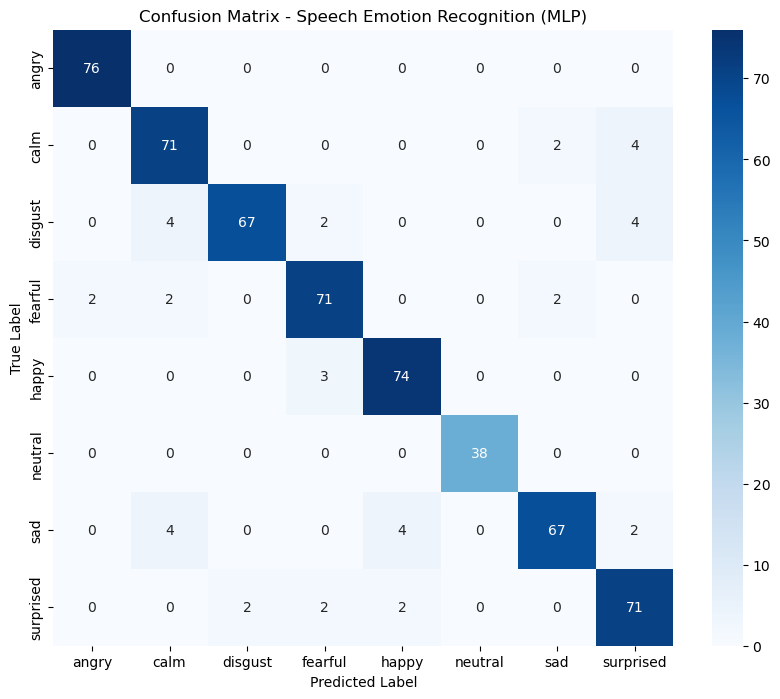

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Speech Emotion Recognition (MLP)")
plt.show()


In [27]:
from sklearn.metrics import accuracy_score

print("✅ Final Model Accuracy:", accuracy_score(y_test, y_pred_mlp))


✅ Final Model Accuracy: 0.9288194444444444


In [28]:
import joblib

joblib.dump(mlp, "emotion_mlp_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("✅ All model files saved successfully")


✅ All model files saved successfully


In [29]:
import os
os.listdir()


['.ipynb_checkpoints',
 'app.py',
 'Data',
 'emotion_mlp_model.pkl',
 'feature_scaler.pkl',
 'label_encoder.pkl',
 'speech_emotion_day1.ipynb.ipynb',
 'speech_emotion_features.csv']

Accuracy: 98.54%

Classification Report:

              precision    recall  f1-score   support

       angry       0.99      1.00      1.00       384
        calm       0.97      0.98      0.98       384
     disgust       0.99      0.97      0.98       384
     fearful       0.98      0.98      0.98       384
       happy       0.98      0.99      0.99       384
     neutral       1.00      1.00      1.00       192
         sad       0.99      0.97      0.98       384
   surprised       0.97      0.98      0.98       384

    accuracy                           0.99      2880
   macro avg       0.99      0.99      0.99      2880
weighted avg       0.99      0.99      0.99      2880



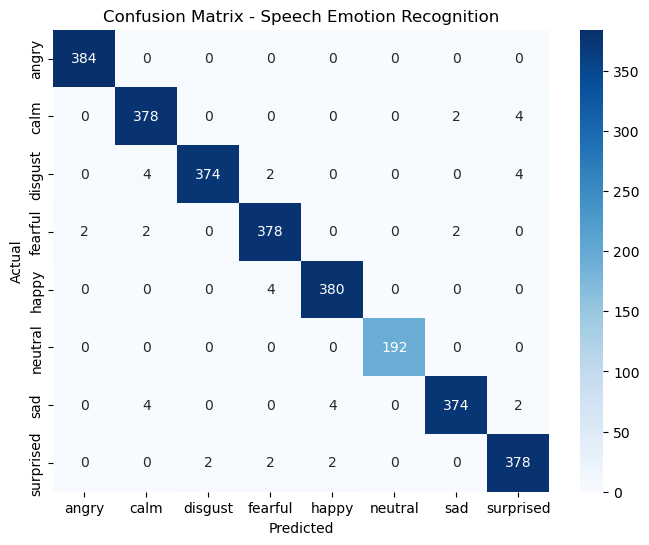

In [14]:

import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Load saved objects
import joblib

model = joblib.load("emotion_mlp_model.pkl")
scaler = joblib.load("feature_scaler.pkl")
label_encoder = joblib.load("label_encoder.pkl")


# Load feature dataset
df = pd.read_csv("speech_emotion_features.csv")

X = df.drop("emotion", axis=1)
y = df["emotion"]

# Encode labels
y_encoded = label_encoder.transform(y)

# Scale features
X_scaled = scaler.transform(X)

# Predict
y_pred = model.predict(X_scaled)

# Metrics
accuracy = accuracy_score(y_encoded, y_pred)
cm = confusion_matrix(y_encoded, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_encoded, y_pred, target_names=label_encoder.classes_))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Speech Emotion Recognition")
plt.show()


In [13]:
import os
print(os.getcwd())
print(os.listdir())


C:\Users\itl\Desktop\speech-emotion-recognition
['.ipynb_checkpoints', 'app.py', 'Data', 'emotion_mlp_model.pkl', 'feature_scaler.pkl', 'label_encoder.pkl', 'speech_emotion_day1.ipynb.ipynb', 'speech_emotion_features.csv']


In [15]:
import pickle

evaluation_results = {
    "accuracy": accuracy,
    "classification_report": classification_report(
        y_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True
    ),
    "confusion_matrix": cm,
    "labels": label_encoder.classes_
}

with open("evaluation_results.pkl", "wb") as f:
    pickle.dump(evaluation_results, f)
